In [2]:


import numpy as np
import pandas as pd
import re
import datetime

In [3]:
# Install Faker if not installed
!pip install faker

import pandas as pd
import random
from datetime import datetime, timedelta
from faker import Faker

# Initialize Faker
faker = Faker()


# -------------------------------
# LOG GENERATOR
# -------------------------------
def generate_synthetic_log(
    log_type,
    ip=None,
    username=None,
    timestamp=None,
    target_ip=None,
    filename=None
):
    ip = ip if ip else faker.ipv4_public()
    username = username if username else faker.user_name()
    timestamp_dt = timestamp if timestamp else faker.date_time_between(start_date='-5y', end_date='now')
    timestamp_str = timestamp_dt.strftime('%a %b %d %H:%M:%S %Y')
    resource = faker.uri_path()

    if log_type == 'authentication-failed':
        return {
            'category': 'authentication-failed',
            'log': f"[{timestamp_str}] [error] [client {ip}] user {username}: authentication failure for \"{resource}\", reason: user not found"
        }

    elif log_type == 'http-request-failure':
        status_code = random.choice([401, 403, 404, 500, 502])
        user_agent = faker.user_agent()
        method = random.choice(['GET', 'POST', 'PUT'])
        return {
            'category': 'http-request-failure',
            'log': f"[{timestamp_str}] [error] [client {ip}] {method} {resource} HTTP/1.1 \"{user_agent}\" {status_code}"
        }

    elif log_type == 'process-info':
        process_name = faker.file_name(extension='exe')
        pid = random.randint(1000, 9999)
        message = faker.sentence()
        return {
            'category': 'process-info',
            'log': f"[{timestamp_str}] [notice] process {process_name}[{pid}]: {message}"
        }

    elif log_type == 'user-session-open':
        session_id = faker.uuid4()
        return {
            'category': 'user-session-open',
            'log': f"[{timestamp_str}] [info] user {username}: session {session_id} opened from {ip}"
        }

    elif log_type == 'network-scan':
        target_ip_val = target_ip if target_ip else faker.ipv4_private()
        port = random.randint(1, 65535)
        return {
            'category': 'network-scan',
            'log': f"[{timestamp_str}] [alert] [source {ip}] detected port scan from {ip} to {target_ip_val} on port {port}"
        }

    elif log_type == 'malware-detection':
        filename_val = filename if filename else faker.file_name()
        malware_name = faker.word()
        return {
            'category': 'malware-detection',
            'log': f"[{timestamp_str}] [critical] [host {ip}] malware detected: {malware_name} in {filename_val}"
        }

    elif log_type == 'data-exfiltration':
        data_size = random.randint(10, 1000)
        protocol = random.choice(['FTP', 'HTTP', 'HTTPS'])
        return {
            'category': 'data-exfiltration',
            'log': f"[{timestamp_str}] [warning] [source {ip}] potential data exfiltration of {data_size}MB via {protocol} to {faker.url()}"
        }

    # ✅ NEW PHISHING LOG
    elif log_type == 'phishing-email':
        sender = faker.email()
        subject = random.choice([
            "Urgent: Password Reset Required",
            "Invoice Attached",
            "Security Alert",
            "Account Suspension Notice"
        ])
        malicious_url = faker.url()

        return {
            'category': 'phishing-email',
            'log': f"[{timestamp_str}] [warning] email received by {username} from {sender} with subject '{subject}' containing suspicious link {malicious_url}"
        }

    else:
        return {
            'category': 'generic',
            'log': f"[{timestamp_str}] [info] [client {ip}] generic log entry: {faker.sentence()}"
        }


# -------------------------------
# DATASET GENERATOR
# -------------------------------
def generate_synthetic_logs_df(num_logs=50000, num_scenarios=200):

    logs_data = []

    all_log_types = [
        'authentication-failed',
        'http-request-failure',
        'process-info',
        'user-session-open',
        'network-scan',
        'malware-detection',
        'data-exfiltration',
        'phishing-email'  # ✅ added
    ]

    for _ in range(num_scenarios):

        scenario_type = random.choice([
            'brute-force',
            'scan-exploit',
            'malware-chain',
            'data-theft',
            'phishing-compromise'  # ✅ NEW
        ])

        source_ip = faker.ipv4_public()
        source_username = faker.user_name()
        scenario_start_time = faker.date_time_between(start_date='-5y', end_date='now')

        # ---------------- brute force
        if scenario_type == 'brute-force':
            for i in range(random.randint(3, 10)):
                log_time = scenario_start_time + timedelta(seconds=i * random.randint(10, 60))
                logs_data.append(generate_synthetic_log(
                    'authentication-failed',
                    ip=source_ip,
                    username=source_username,
                    timestamp=log_time
                ))

        # ---------------- scan exploit
        elif scenario_type == 'scan-exploit':
            target_ip = faker.ipv4_private()

            logs_data.append(generate_synthetic_log(
                'network-scan',
                ip=source_ip,
                timestamp=scenario_start_time,
                target_ip=target_ip
            ))

            logs_data.append(generate_synthetic_log(
                'http-request-failure',
                ip=source_ip,
                username=source_username,
                timestamp=scenario_start_time + timedelta(minutes=random.randint(1, 10))
            ))

        # ---------------- malware chain
        elif scenario_type == 'malware-chain':
            logs_data.append(generate_synthetic_log(
                'user-session-open',
                ip=source_ip,
                username=source_username,
                timestamp=scenario_start_time
            ))

            logs_data.append(generate_synthetic_log(
                'process-info',
                ip=source_ip,
                username=source_username,
                timestamp=scenario_start_time + timedelta(minutes=random.randint(5, 20))
            ))

            logs_data.append(generate_synthetic_log(
                'malware-detection',
                ip=source_ip,
                username=source_username,
                timestamp=scenario_start_time + timedelta(minutes=random.randint(20, 60)),
                filename=faker.file_name(extension='dll')
            ))

        # ---------------- data theft
        elif scenario_type == 'data-theft':
            logs_data.append(generate_synthetic_log(
                'user-session-open',
                ip=source_ip,
                username=source_username,
                timestamp=scenario_start_time
            ))

            logs_data.append(generate_synthetic_log(
                'data-exfiltration',
                ip=source_ip,
                username=source_username,
                timestamp=scenario_start_time + timedelta(minutes=random.randint(10, 45))
            ))

        # ---------------- ✅ PHISHING ATTACK CHAIN
        elif scenario_type == 'phishing-compromise':

            # phishing email
            logs_data.append(generate_synthetic_log(
                'phishing-email',
                ip=source_ip,
                username=source_username,
                timestamp=scenario_start_time
            ))

            # login after click
            logs_data.append(generate_synthetic_log(
                'user-session-open',
                ip=source_ip,
                username=source_username,
                timestamp=scenario_start_time + timedelta(minutes=random.randint(2, 15))
            ))

            # malware execution
            logs_data.append(generate_synthetic_log(
                'malware-detection',
                ip=source_ip,
                username=source_username,
                timestamp=scenario_start_time + timedelta(minutes=random.randint(15, 40))
            ))

            # data exfiltration
            logs_data.append(generate_synthetic_log(
                'data-exfiltration',
                ip=source_ip,
                username=source_username,
                timestamp=scenario_start_time + timedelta(minutes=random.randint(40, 90))
            ))

    # Fill remaining logs randomly
    remaining_logs_count = num_logs - len(logs_data)

    for _ in range(remaining_logs_count):
        logs_data.append(generate_synthetic_log(random.choice(all_log_types)))

    return pd.DataFrame(logs_data)


# -------------------------------
# GENERATE DATA
# -------------------------------
df = generate_synthetic_logs_df(num_logs=50000, num_scenarios=200)

print(df.shape)
df.head()


Defaulting to user installation because normal site-packages is not writeable
(50000, 2)


,category,log
0,network-scan,[Mon Apr 10 20:06:20 2023] [alert] [source 114...
1,http-request-failure,[Mon Apr 10 20:15:20 2023] [error] [client 114...
2,user-session-open,[Thu Nov 18 14:39:44 2021] [info] user mindymo...
3,data-exfiltration,[Thu Nov 18 14:55:44 2021] [warning] [source 1...
4,phishing-email,[Sat May 14 12:07:11 2022] [warning] email rec...


In [4]:
import pandas as pd
import re
from datetime import datetime

def flexible_log_parser(df):
    """Parse logs with flexible pattern matching"""

    results = []

    for idx, row in df.iterrows():
        try:
            log_text = row['log']
            category = row['category']

            # Extract timestamp - everything between first [ and ]
            timestamp_match = re.search(r'\[(.*?)\]', log_text)
            if not timestamp_match:
                continue

            date_str = timestamp_match.group(1)

            # Try to parse the date
            try:
                # Try different date formats
                if len(date_str.split()) == 5:  # "Thu Dec 17 02:47:06 1992"
                    dt = datetime.strptime(date_str, '%a %b %d %H:%M:%S %Y')
                elif len(date_str.split()) == 4:  # "Dec 17 02:47:06 1992"
                    dt = datetime.strptime(date_str, '%b %d %H:%M:%S %Y')
                else:
                    continue
            except:
                continue

            # Extract IP - look for "client X.X.X.X", "source X.X.X.X", or "host X.X.X.X"
            ip_match = re.search(r'(?:client|source|host)\s+([\d.]+)', log_text)
            ip = ip_match.group(1) if ip_match else 'unknown'

            # Extract username - look for "user name:"
            user_match = re.search(r'user (\w+):', log_text)
            username = user_match.group(1) if user_match else 'unknown'

            # Extract resource - look for "/something"
            resource_match = re.search(r'"(/[^\"]+)"', log_text)
            resource = resource_match.group(1) if resource_match else 'unknown'

            results.append({
                'timestamp': dt.isoformat() + 'Z',
                'source_ip': ip,
                'username': username,
                'resource': resource,
                'category': category,
                'year': dt.year,
                'month': dt.month,
                'day': dt.day,
                'hour': dt.hour,
                'minute': dt.minute,
                'second': dt.second,
                'weekday': dt.strftime('%a'),
                'raw_log': log_text[:100]  # For debugging
            })

        except Exception as e:
            continue

    return pd.DataFrame(results)

# Run it
df_parsed = flexible_log_parser(df)
df_parsed.head()

,timestamp,source_ip,username,resource,category,year,month,day,hour,minute,second,weekday,raw_log
0,2023-04-10T20:06:20Z,114.176.252.245,unknown,unknown,network-scan,2023,4,10,20,6,20,Mon,[Mon Apr 10 20:06:20 2023] [alert] [source 114...
1,2023-04-10T20:15:20Z,114.176.252.245,unknown,unknown,http-request-failure,2023,4,10,20,15,20,Mon,[Mon Apr 10 20:15:20 2023] [error] [client 114...
2,2021-11-18T14:39:44Z,unknown,mindymoore,unknown,user-session-open,2021,11,18,14,39,44,Thu,[Thu Nov 18 14:39:44 2021] [info] user mindymo...
3,2021-11-18T14:55:44Z,196.6.41.166,unknown,unknown,data-exfiltration,2021,11,18,14,55,44,Thu,[Thu Nov 18 14:55:44 2021] [warning] [source 1...
4,2022-05-14T12:07:11Z,unknown,unknown,unknown,phishing-email,2022,5,14,12,7,11,Sat,[Sat May 14 12:07:11 2022] [warning] email rec...


In [5]:
df_parsed.head(n=10)

,timestamp,source_ip,username,resource,category,year,month,day,hour,minute,second,weekday,raw_log
0,2023-04-10T20:06:20Z,114.176.252.245,unknown,unknown,network-scan,2023,4,10,20,6,20,Mon,[Mon Apr 10 20:06:20 2023] [alert] [source 114...
1,2023-04-10T20:15:20Z,114.176.252.245,unknown,unknown,http-request-failure,2023,4,10,20,15,20,Mon,[Mon Apr 10 20:15:20 2023] [error] [client 114...
2,2021-11-18T14:39:44Z,unknown,mindymoore,unknown,user-session-open,2021,11,18,14,39,44,Thu,[Thu Nov 18 14:39:44 2021] [info] user mindymo...
3,2021-11-18T14:55:44Z,196.6.41.166,unknown,unknown,data-exfiltration,2021,11,18,14,55,44,Thu,[Thu Nov 18 14:55:44 2021] [warning] [source 1...
4,2022-05-14T12:07:11Z,unknown,unknown,unknown,phishing-email,2022,5,14,12,7,11,Sat,[Sat May 14 12:07:11 2022] [warning] email rec...
5,2022-05-14T12:09:11Z,unknown,curtis74,unknown,user-session-open,2022,5,14,12,9,11,Sat,[Sat May 14 12:09:11 2022] [info] user curtis7...
6,2022-05-14T12:35:11Z,88.230.59.140,unknown,unknown,malware-detection,2022,5,14,12,35,11,Sat,[Sat May 14 12:35:11 2022] [critical] [host 88...
7,2022-05-14T13:29:11Z,88.230.59.140,unknown,unknown,data-exfiltration,2022,5,14,13,29,11,Sat,[Sat May 14 13:29:11 2022] [warning] [source 8...
8,2022-10-09T13:31:49Z,unknown,leslie31,unknown,user-session-open,2022,10,9,13,31,49,Sun,[Sun Oct 09 13:31:49 2022] [info] user leslie3...
9,2022-10-09T13:50:49Z,unknown,unknown,unknown,process-info,2022,10,9,13,50,49,Sun,[Sun Oct 09 13:50:49 2022] [notice] process ho...


In [6]:
df_parsed.shape

(50000, 13)

In [7]:
def group_into_events(df, time_window_minutes=5):
    """
    Group related logs into security events based on:
    - Time proximity
    - Same source/category
    - Sequential patterns
    """

    # Sort by timestamp
    df = df.sort_values('timestamp').reset_index(drop=True)

    events = []
    current_event = None

    for idx, row in df.iterrows():
        if current_event is None:
            # Start new event
            current_event = {
                'event_id': len(events) + 1,
                'start_time': row['timestamp'],
                'end_time': row['timestamp'],
                'source_ip': row['source_ip'],
                'username': row['username'],
                'resource': row['resource'],
                'category': row['category'],
                'log_count': 1,
                'log_indices': [idx],
                'severity_score': 0,
                'raw_samples': [row['raw_log'][:200]]  # First 200 chars
            }
        else:
            # Check if this log belongs to current event
            time_diff = (pd.to_datetime(row['timestamp']) -
                        pd.to_datetime(current_event['end_time'])).total_seconds() / 60

            same_source = (row['source_ip'] == current_event['source_ip'] or
                          row['username'] == current_event['username'])

            same_category = (row['category'] == current_event['category'])

            # Belongs to same event if within time window AND (same source or category)
            if time_diff <= time_window_minutes and (same_source or same_category):
                current_event['end_time'] = row['timestamp']
                current_event['log_count'] += 1
                current_event['log_indices'].append(idx)
                if len(current_event['raw_samples']) < 3:  # Keep max 3 samples
                    current_event['raw_samples'].append(row['raw_log'][:200])
            else:
                # Save current event and start new one
                events.append(current_event)
                current_event = {
                    'event_id': len(events) + 1,
                    'start_time': row['timestamp'],
                    'end_time': row['timestamp'],
                    'source_ip': row['source_ip'],
                    'username': row['username'],
                    'resource': row['resource'],
                    'category': row['category'],
                    'log_count': 1,
                    'log_indices': [idx],
                    'severity_score': 0,
                    'raw_samples': [row['raw_log'][:200]]
                }

    # Don't forget the last event
    if current_event:
        events.append(current_event)

    return pd.DataFrame(events)

# Group your logs
events_df = group_into_events(df_parsed)
# events_df = events_df.sort_values('log_count').reset_index(drop=True)

events_df.sample(n=10)

,event_id,start_time,end_time,source_ip,username,resource,category,log_count,log_indices,severity_score,raw_samples
30957,30958,2024-06-16T16:01:12Z,2024-06-16T16:01:12Z,unknown,unknown,unknown,process-info,1,[33048],0,[[Sun Jun 16 16:01:12 2024] [notice] process g...
24488,24489,2023-10-04T08:09:18Z,2023-10-04T08:09:18Z,100.208.42.146,unknown,unknown,http-request-failure,1,[26164],0,[[Wed Oct 04 08:09:18 2023] [error] [client 10...
3035,3036,2021-06-19T15:24:26Z,2021-06-19T15:24:26Z,unknown,unknown,unknown,process-info,1,[3233],0,[[Sat Jun 19 15:24:26 2021] [notice] process p...
17622,17623,2023-01-04T06:42:14Z,2023-01-04T06:42:14Z,192.106.46.227,unknown,unknown,data-exfiltration,1,[18859],0,[[Wed Jan 04 06:42:14 2023] [warning] [source ...
46363,46364,2026-02-01T02:42:19Z,2026-02-01T02:42:19Z,unknown,unknown,unknown,process-info,1,[49494],0,[[Sun Feb 01 02:42:19 2026] [notice] process w...
18618,18619,2023-02-12T04:25:36Z,2023-02-12T04:25:36Z,190.121.177.63,sking,unknown,authentication-failed,1,[19913],0,[[Sun Feb 12 04:25:36 2023] [error] [client 19...
6094,6095,2021-10-17T16:30:45Z,2021-10-17T16:30:45Z,133.57.89.76,unknown,unknown,malware-detection,1,[6517],0,[[Sun Oct 17 16:30:45 2021] [critical] [host 1...
9795,9796,2022-03-09T04:24:45Z,2022-03-09T04:24:45Z,198.30.121.59,unknown,unknown,data-exfiltration,1,[10451],0,[[Wed Mar 09 04:24:45 2022] [warning] [source ...
45444,45445,2025-12-29T07:28:25Z,2025-12-29T07:28:25Z,14.60.225.189,unknown,unknown,network-scan,1,[48525],0,[[Mon Dec 29 07:28:25 2025] [alert] [source 14...
44826,44827,2025-12-06T02:42:41Z,2025-12-06T02:42:41Z,unknown,tsavage,unknown,user-session-open,1,[47861],0,[[Sat Dec 06 02:42:41 2025] [info] user tsavag...


In [8]:
events_df.shape

(46840, 11)


Events by Category:
category
authentication-failed    6319
user-session-open        6063
http-request-failure     5817
phishing-email           5798
malware-detection        5766
process-info             5725
data-exfiltration        5715
network-scan             5637
Name: count, dtype: int64

Average Score by Category:
category
authentication-failed    0.0
data-exfiltration        0.0
http-request-failure     0.0
malware-detection        0.0
network-scan             0.0
phishing-email           0.0
process-info             0.0
user-session-open        0.0
Name: severity_score, dtype: float64


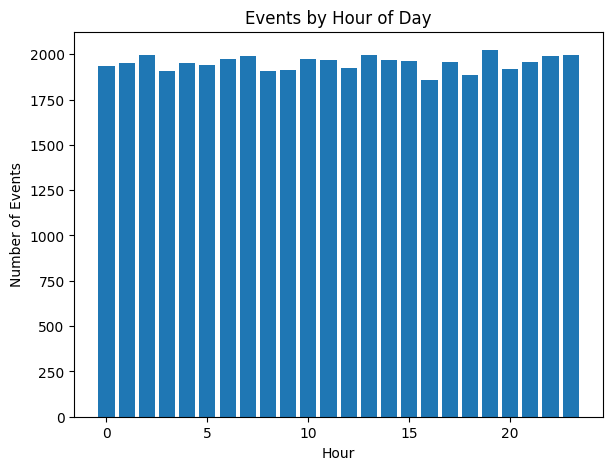

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Events over time
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
events_by_hour = pd.to_datetime(events_df['start_time']).dt.hour.value_counts().sort_index()
plt.bar(events_by_hour.index, events_by_hour.values)
plt.title('Events by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Number of Events')

# Category breakdown
print("\nEvents by Category:")
print(events_df['category'].value_counts())

print("\nAverage Score by Category:")
print(events_df.groupby('category')['severity_score'].mean().sort_values(ascending=False))

In [10]:
import pandas as pd
import numpy as np
from datetime import timedelta
from collections import defaultdict
import networkx as nx

def temporal_correlation(events_df, time_window_minutes=30):
    """
    Find events that occur close together in time
    """
    events_df = events_df.copy()
    events_df['start_dt'] = pd.to_datetime(events_df['start_time'])
    events_df = events_df.sort_values('start_dt')

    correlations = []

    for i, event1 in events_df.iterrows():
        # Find events within time window after this event
        time_mask = (
            (events_df['start_dt'] > event1['start_dt']) &
            (events_df['start_dt'] <= event1['start_dt'] + timedelta(minutes=time_window_minutes))
        )

        following_events = events_df[time_mask]

        for j, event2 in following_events.iterrows():
            correlation = {
                'source_event': event1['event_id'],
                'target_event': event2['event_id'],
                'time_diff_minutes': (event2['start_dt'] - event1['start_dt']).total_seconds() / 60,
                'source_category': event1['category'],
                'target_category': event2['category'],
                'source_ip': event1['source_ip'],
                'target_ip': event2['source_ip'],
                'username': event1['username'] if event1['username'] == event2['username'] else 'different',
                'correlation_type': 'temporal',
                'confidence': 0.6  # Base confidence
            }

            # Boost confidence if same source/user
            if event1['source_ip'] == event2['source_ip'] and event1['source_ip'] != 'unknown':
                correlation['confidence'] += 0.3
            if event1['username'] == event2['username'] and event1['username'] != 'unknown':
                correlation['confidence'] += 0.2

            correlations.append(correlation)

    return pd.DataFrame(correlations)

# Run temporal correlation
temporal_corr = temporal_correlation(events_df)
temporal_corr.head()

,source_event,target_event,time_diff_minutes,source_category,target_category,source_ip,target_ip,username,correlation_type,confidence
0,5,6,20.066667,network-scan,malware-detection,38.123.32.28,209.79.50.64,unknown,temporal,0.6
1,6,7,15.016667,malware-detection,http-request-failure,209.79.50.64,213.33.9.54,unknown,temporal,0.6
2,9,10,13.550000,data-exfiltration,malware-detection,193.55.76.122,156.182.134.44,unknown,temporal,0.6
3,11,12,5.383333,phishing-email,authentication-failed,unknown,206.214.119.186,different,temporal,0.6
4,13,14,7.883333,network-scan,malware-detection,178.219.62.25,106.137.53.109,unknown,temporal,0.6


In [ ]:
def kill_chain_correlation(events_df):
    """
    Map events to MITRE ATT&CK kill chain phases
    """

    
    kill_chain_mapping = {
        'process-info': 'execution',
        'authentication-failed': 'credential-access', # Corrected category
        'network-scan': 'reconnaissance', # Added category
        'http-request-failure': 'defense-evasion',
        'malware-detection': 'execution', # Added category
        'data-exfiltration': 'exfiltration', # Added category
        'user-session-open': 'initial-access' # Added category
    }

    events_df = events_df.copy()
    events_df['kill_chain_phase'] = events_df['category'].map(
        lambda x: kill_chain_mapping.get(x, 'unknown')
    )
    events_df['start_dt'] = pd.to_datetime(events_df['start_time'])

    # Group by source IP to find attack chains
    kill_chain_correlations = []

    for ip in events_df['source_ip'].unique():
        if ip == 'unknown':
            continue

        ip_events = events_df[events_df['source_ip'] == ip].sort_values('start_dt')

        # Track phases seen
        phases_seen = set()
        chain_start = None

        for idx, event in ip_events.iterrows():
            phase = event['kill_chain_phase']

            # If this event's phase is a progression in the chain (not already seen)
            if phase not in phases_seen and phase != 'unknown':
                if len(phases_seen) > 0 and chain_start is not None:
                    # This is a new phase in the attack chain
                    kill_chain_correlations.append({
                        'source_ip': ip,
                        'username': event['username'],
                        'chain_start': chain_start,
                        'current_event': event['event_id'],
                        'current_phase': phase,
                        'phases_completed': list(phases_seen),
                        'phase_count': len(phases_seen) + 1,
                        'time_from_start': (event['start_dt'] - chain_start).total_seconds() / 3600,
                        'confidence': 0.5 + (len(phases_seen) * 0.1),  # More phases = higher confidence
                        'correlation_type': 'kill_chain'
                    })

                phases_seen.add(phase)
                if chain_start is None:
                    chain_start = event['start_dt']

    return pd.DataFrame(kill_chain_correlations)


kill_chain_corr = kill_chain_correlation(events_df)
print(f"Found {len(kill_chain_corr)} kill chain progressions")
print(kill_chain_corr.head())

Found 53 kill chain progressions
         source_ip username               chain_start  current_event  \
0    219.23.201.28  unknown 2021-02-22 13:04:33+00:00             80   
1   155.132.173.11  unknown 2021-02-24 10:04:33+00:00            139   
2  177.241.192.121  unknown 2021-05-01 18:10:22+00:00           1833   
3   214.240.122.59  unknown 2021-07-05 04:21:11+00:00           3447   
4   198.133.141.49  unknown 2021-09-01 06:11:15+00:00           4939   

     current_phase  phases_completed  phase_count  time_from_start  \
0     exfiltration       [execution]            2         0.866667   
1     exfiltration       [execution]            2         0.500000   
2     exfiltration       [execution]            2         0.700000   
3     exfiltration       [execution]            2         1.166667   
4  defense-evasion  [reconnaissance]            2         0.150000   

   confidence correlation_type  
0         0.6       kill_chain  
1         0.6       kill_chain  
2         0.6 

In [12]:
def pattern_recognition(events_df, min_sequence_length=2):
    """
    Find recurring patterns of event sequences
    """
    from collections import Counter

    events_df = events_df.copy()
    events_df['start_dt'] = pd.to_datetime(events_df['start_time'])

    # Group by source IP and create sequences
    ip_sequences = {}

    for ip in events_df['source_ip'].unique():
        if ip == 'unknown':
            continue

        ip_events = events_df[events_df['source_ip'] == ip].sort_values('start_dt')
        if len(ip_events) >= min_sequence_length:
            # Create category sequence
            sequence = tuple(ip_events['category'].tolist())
            ip_sequences[ip] = {
                'sequence': sequence,
                'events': ip_events['event_id'].tolist(),
                'timestamps': ip_events['start_dt'].tolist()
            }

    # Find common patterns
    all_sequences = [v['sequence'] for v in ip_sequences.values()]
    pattern_counts = Counter(all_sequences)

    # Extract patterns
    patterns = []
    for sequence, count in pattern_counts.items():
        if count >= 2:  # Pattern appears at least twice
            # Find example IPs
            example_ips = [ip for ip, data in ip_sequences.items()
                          if data['sequence'] == sequence][:3]

            patterns.append({
                'pattern': ' → '.join(sequence),
                'frequency': count,
                'example_ips': example_ips,
                'length': len(sequence),
                'confidence': min(0.9, 0.5 + (count * 0.1)),
                'correlation_type': 'pattern'
            })

    return pd.DataFrame(patterns)


patterns_df = pattern_recognition(events_df, min_sequence_length=1)
patterns_df.head()

,pattern,frequency,example_ips,length,confidence,correlation_type
0,data-exfiltration,5678,"[209.203.220.196, 193.55.76.122, 189.20.189.200]",1,0.9,pattern
1,authentication-failed,6317,"[203.62.40.50, 40.62.73.30, 206.214.119.186]",1,0.9,pattern
2,malware-detection,5729,"[82.225.91.207, 209.79.50.64, 156.182.134.44]",1,0.9,pattern
3,network-scan,5621,"[38.123.32.28, 178.219.62.25, 31.208.238.111]",1,0.9,pattern
4,http-request-failure,5801,"[213.33.9.54, 90.71.13.149, 11.106.49.161]",1,0.9,pattern


In [13]:
def entity_correlation(events_df, time_window_hours=8760):
    """
    Correlate events by same actor (IP/username) across different targets
    """
    events_df = events_df.copy()
    events_df['start_dt'] = pd.to_datetime(events_df['start_time'])

    entity_correlations = []

    # Group by source IP
    for entity_type in ['source_ip', 'username']:
        for entity_value in events_df[entity_type].unique():
            if entity_value == 'unknown' or pd.isna(entity_value):
                continue

            entity_events = events_df[events_df[entity_type] == entity_value].sort_values('start_dt')

            if len(entity_events) < 2:
                continue

            # Find distinct targets (resource/destinations)
            unique_targets = entity_events['resource'].nunique()
            unique_categories = entity_events['category'].nunique()
            time_span = (entity_events['start_dt'].max() - entity_events['start_dt'].min()).total_seconds() / 3600

            if unique_targets > 1 or unique_categories > 1:
                entity_correlations.append({
                    'entity_type': entity_type,
                    'entity_value': entity_value,
                    'event_count': len(entity_events),
                    'unique_targets': unique_targets,
                    'unique_categories': unique_categories,
                    'time_span_hours': time_span,
                    'avg_events_per_hour': len(entity_events) / max(time_span, 1),
                    'categories': entity_events['category'].tolist(),
                    'event_ids': entity_events['event_id'].tolist(),
                    'confidence': 0.7 if unique_categories > 2 else 0.5,
                    'correlation_type': 'entity_behavior'
                })

    return pd.DataFrame(entity_correlations)


entity_corr = entity_correlation(events_df)
print(f"Found {len(entity_corr)} entity-based correlations")
entity_corr.head()

Found 453 entity-based correlations


,entity_type,entity_value,event_count,unique_targets,unique_categories,time_span_hours,avg_events_per_hour,categories,event_ids,confidence,correlation_type
0,source_ip,219.23.201.28,2,1,2,0.866667,2.000000,"[malware-detection, data-exfiltration]","[79, 80]",0.5,entity_behavior
1,source_ip,155.132.173.11,2,1,2,0.500000,2.000000,"[malware-detection, data-exfiltration]","[138, 139]",0.5,entity_behavior
2,source_ip,177.241.192.121,2,1,2,0.700000,2.000000,"[malware-detection, data-exfiltration]","[1832, 1833]",0.5,entity_behavior
3,source_ip,214.240.122.59,2,1,2,1.166667,1.714286,"[malware-detection, data-exfiltration]","[3444, 3447]",0.5,entity_behavior
4,source_ip,198.133.141.49,2,1,2,0.150000,2.000000,"[network-scan, http-request-failure]","[4938, 4939]",0.5,entity_behavior


In [14]:
def build_incidents_from_correlations(all_events_df, temporal_corr, kill_chain_corr, patterns_df, entity_corr, incidents_df):
    # Start with graph-based incidents
    if len(incidents_df) > 0:
        incidents = incidents_df.to_dict('records')
    else:
        incidents = []

    # Add kill chain progressions as incidents
    if len(kill_chain_corr) > 0:
        for idx, chain in kill_chain_corr.iterrows():
            # Check if this chain is already in an incident
            chain_events = set()
            if 'event_ids' in chain and chain['event_ids']:
                chain_events = set(chain['event_ids'])

            # Find matching incident or create new
            found = False
            for inc in incidents:
                if any(e in inc['events'] for e in chain_events):
                    # Merge
                    inc['events'] = list(set(inc['events']).union(chain_events))
                    inc['kill_chain_phases'] = chain['phases_completed']
                    found = True
                    break

            if not found and len(chain_events) > 0:
                incidents.append({
                    'incident_id': f"KC-{len(incidents)+1:03d}",
                    'event_count': len(chain_events),
                    'events': list(chain_events),
                    'kill_chain_phases': chain['phases_completed'],
                    'source_ip': chain.get('source_ip', 'unknown'),
                    'detection_type': 'kill_chain'
                })

    # Score and prioritize incidents
    for inc in incidents:
        # Get all events in this incident
        inc_events = all_events_df[all_events_df['event_id'].isin(inc['events'])]

        # Calculate composite score
        inc['total_severity'] = inc_events['severity_score'].sum()
        inc['avg_severity'] = inc_events['severity_score'].mean()
        inc['max_severity'] = inc_events['severity_score'].max()
        inc['unique_categories'] = inc_events['category'].nunique()
        inc['time_span'] = (pd.to_datetime(inc_events['start_time'].max()) -
                           pd.to_datetime(inc_events['start_time'].min())).total_seconds() / 3600

        # Priority scoring
        inc['priority_score'] = (
            inc['avg_severity'] * 0.3 +
            inc['max_severity'] * 0.3 +
            inc['event_count'] * 2 +
            inc['unique_categories'] * 5
        )

        # Priority level
        if inc['priority_score'] > 50:
            inc['priority'] = 'CRITICAL'
        elif inc['priority_score'] > 30:
            inc['priority'] = 'HIGH'
        elif inc['priority_score'] > 15:
            inc['priority'] = 'MEDIUM'
        else:
            inc['priority'] = 'LOW'

    # Sort by priority
    incidents = sorted(incidents, key=lambda x: x['priority_score'], reverse=True)

    return pd.DataFrame(incidents)

# Initialize incidents_df as an empty DataFrame if it's the first run
incidents_df = pd.DataFrame() # Add this line to define incidents_df

# Build final incidents
final_incidents = build_incidents_from_correlations(
    events_df, temporal_corr, kill_chain_corr,
    patterns_df, entity_corr, incidents_df
)

print("\n" + "="*80)
print("FINAL CORRELATED INCIDENTS")
print("="*80)

if len(final_incidents) > 0:
    for idx, inc in final_incidents.head().iterrows():
        print(f"\n{inc['incident_id']} [{inc['priority']}]")
        print(f"  Events: {inc['event_count']} | Severity: {inc['total_severity']:.0f}")
        print(f"  Categories: {inc.get('unique_categories', 'N/A')}")
        print(f"  Time Span: {inc.get('time_span', 0):.1f} hours")
        if 'kill_chain_phases' in inc:
            print(f"  Kill Chain: {' \u2192 '.join(inc['kill_chain_phases'])}")
else:
    print("No significant correlations found")


FINAL CORRELATED INCIDENTS
No significant correlations found


In [16]:
import json
from langchain_ollama import OllamaLLM
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

# Convert dataframe → JSON
kill_chain_corr_json = kill_chain_corr.to_json(orient="records")

# Initialize Ollama
llm = OllamaLLM(
    model="mistral",
    temperature=0.3
)

# Prompt
prompt = PromptTemplate.from_template("""
You are an expert SOC (Security Operations Center) analyst.

You are given correlated cybersecurity event logs in JSON format.
Your job is to analyze attack behaviour — NOT summarize text.

Follow this STRICT analysis workflow:

STEP 1 — Identify Attack Indicators
- suspicious categories
- repeated IPs
- abnormal sequences
- phishing or malware signals

STEP 2 — Detect Attack Type
Classify if this resembles:
- phishing attack
- malware infection
- brute force
- reconnaissance
- data exfiltration
- multi-stage kill chain attack

STEP 3 — Cyber Kill Chain Mapping
Map observed behaviour to stages:
Reconnaissance
Weaponization
Delivery
Exploitation
Installation
Command & Control
Actions on Objectives

STEP 4 — Risk Assessment
Provide:
- severity (Low / Medium / High / Critical)
- confidence score (0–1)
- reasoning

STEP 5 — SOC Recommendations
Give actionable steps:
- containment
- investigation
- prevention

IMPORTANT RULES:
- Base conclusions ONLY on provided logs.
- Do NOT invent events.
- If evidence is weak, say "insufficient evidence".
- Think like a real incident responder.

=====================
LOG DATA:
{logs}
=====================

Return output in this JSON format:

{{
  "attack_detected": "",
  "attack_type": "",
  "kill_chain_stages": [],
  "severity": "",
  "confidence": "",
  "analysis_summary": "",
  "recommended_actions": []
}}

""")

# Create pipeline
chain = prompt | llm | StrOutputParser()

# Run
result = chain.invoke({"logs": kill_chain_corr_json})

print(result)


C:\Users\adity\AppData\Local\Temp\ipykernel_20960\20980139.py:7: Pandas4Warning: The default 'epoch' date format is deprecated and will be removed in a future version, please use 'iso' date format instead.
  kill_chain_corr_json = kill_chain_corr.to_json(orient="records")


 {
  "attack_detected": "Yes",
  "attack_type": "Data Exfiltration",
  "kill_chain_stages": [
    {
      "stage": "Reconnaissance",
      "count": 26
    },
    {
      "stage": "Initial Access",
      "count": 0
    },
    {
      "stage": "Establish Foothold",
      "count": 0
    },
    {
      "stage": "Internal Reconnaissance",
      "count": 0
    },
    {
      "stage": "Lateral Movement",
      "count": 0
    },
    {
      "stage": "Command and Control",
      "count": 0
    },
    {
      "stage": "Data Exfiltration",
      "count": 54
    },
    {
      "stage": "Maintain Access",
      "count": 0
    }
  ],
  "severity": "High",
  "confidence": "High",
  "analysis_summary": "An extensive data exfiltration attack has been detected. The attacker has primarily focused on the Data Exfiltration stage, with multiple instances of data being sent out from various sources.",
  "recommended_actions": [
    "Investigate the source and extent of the data breach",
    "Isolate affected